# Multivariate missing data

Multivariate feeds lose data too — a sensor drops out, a market halts, a region stops reporting. SynForecast applies the same [missingness](missingness) patterns to multivariate generators (`VAR`, `CopulaGenerator`), so you can test multivariate imputation and check that a model still recovers the cross-series structure through the gaps.

::: {.callout-note}
## Independent gaps, shared structure

Each channel receives its *own* missing pattern — the series don't drop out in lockstep — while the correlation between them is left intact, because missingness is applied after the correlated values are generated. The final section confirms the cross-series correlation survives.
:::

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from synforecast.generators import CopulaGenerator, VARGenerator

## VAR Generator with Random Missing Data

Generate 3 correlated series from a VAR(1) model with 15% random missing data.

In [ ]:
var_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "lag_order": 1,
    "missing_data": True,
    "missing_pattern": "random",
    "missing_rate": 0.15,
    "seed": 42,
}

var_gen = VARGenerator(engine="polars", **var_params)
df_var = var_gen.generate(n_series=3)

print(
    f"Generated {df_var['unique_id'].n_unique()} correlated series with VAR(1) model"
)
print(f"Total observations: {len(df_var)}")
df_var.head(30)

Generated 3 correlated series with VAR(1) model
Total observations: 600


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,2.057667
"""0""",2000-01-02 00:00:00,0.295293
"""0""",2000-01-03 00:00:00,0.893053
"""0""",2000-01-04 00:00:00,0.235888
"""0""",2000-01-05 00:00:00,NaN
…,…,…
"""0""",2000-01-26 00:00:00,0.474074
"""0""",2000-01-27 00:00:00,NaN
"""0""",2000-01-28 00:00:00,0.068059


In [ ]:
print("Missing data statistics by series:")
for series_id in df_var["unique_id"].unique().sort():
    series_df = df_var.filter(pl.col("unique_id") == series_id)
    values = series_df["y"].to_numpy()
    nan_count = np.sum(np.isnan(values))
    nan_rate = nan_count / len(values)
    print(f"  {series_id}: {nan_count} missing ({nan_rate:.1%})")

Missing data statistics by series:
  0: 30 missing (15.0%)
  1: 30 missing (15.0%)
  2: 30 missing (15.0%)


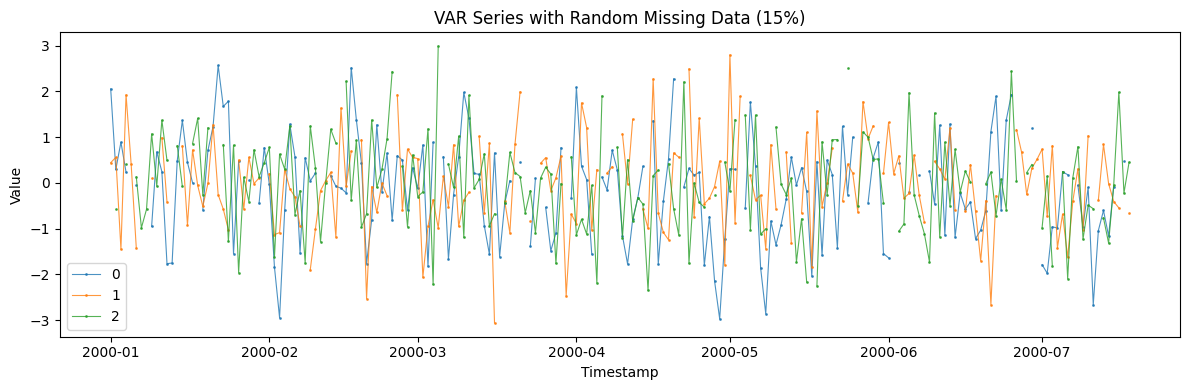

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_var["unique_id"].unique().to_list():
    series = df_var.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("VAR Series with Random Missing Data (15%)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Copula Generator with Block Missing Data

Generate correlated series using a Gaussian copula with week-long missing blocks, simulating synchronized outages.

In [ ]:
correlation_matrix = np.array([[1.0, 0.7, 0.3], [0.7, 1.0, 0.5], [0.3, 0.5, 1.0]])

copula_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "copula_type": "gaussian",
    "correlation_matrix": correlation_matrix,
    "missing_data": True,
    "missing_pattern": "block",
    "missing_rate": 0.2,
    "missing_block_size": 7,
    "seed": 123,
}

copula_gen = CopulaGenerator(engine="polars", **copula_params)
df_copula = copula_gen.generate(n_series=3)

print(
    f"Generated {df_copula['unique_id'].n_unique()} correlated series with Gaussian copula"
)
print(f"Missing blocks of size: {copula_params['missing_block_size']} days")
df_copula.head(40)

Generated 3 correlated series with Gaussian copula
Missing blocks of size: 7 days


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,1.05608
"""0""",2000-01-02 00:00:00,0.436385
"""0""",2000-01-03 00:00:00,0.680307
"""0""",2000-01-04 00:00:00,-0.158773
"""0""",2000-01-05 00:00:00,-0.99138
…,…,…
"""0""",2000-02-05 00:00:00,0.293606
"""0""",2000-02-06 00:00:00,0.504607
"""0""",2000-02-07 00:00:00,NaN


In [ ]:
print("Block missing statistics by series:")
for series_id in df_copula["unique_id"].unique().sort():
    series_df = df_copula.filter(pl.col("unique_id") == series_id)
    values = series_df["y"].to_numpy()
    nan_count = np.sum(np.isnan(values))
    nan_rate = nan_count / len(values)

    max_consecutive = 0
    current_consecutive = 0
    for val in values:
        if np.isnan(val):
            current_consecutive += 1
            max_consecutive = max(max_consecutive, current_consecutive)
        else:
            current_consecutive = 0

    print(
        f"  {series_id}: {nan_count} missing ({nan_rate:.1%}), "
        f"max block: {max_consecutive} days"
    )

Block missing statistics by series:
  0: 33 missing (16.5%), max block: 12 days
  1: 35 missing (17.5%), max block: 7 days
  2: 30 missing (15.0%), max block: 9 days


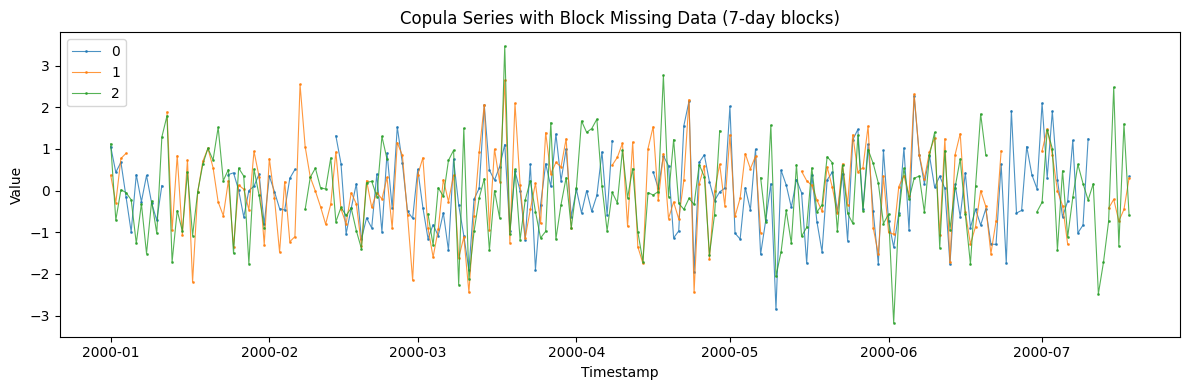

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_copula["unique_id"].unique().to_list():
    series = df_copula.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("Copula Series with Block Missing Data (7-day blocks)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## VAR with Seasonal Missing Data (Weekend Gaps)

Simulate a year of VAR(2) data with weekly seasonal missing patterns, representing weekend reporting gaps.

In [ ]:
var_seasonal_params = {
    "min_length": 365,
    "max_length": 365,
    "freq": "D",
    "lag_order": 2,
    "missing_data": True,
    "missing_pattern": "seasonal",
    "missing_rate": 0.12,
    "missing_seasonal_period": 7,
    "seed": 456,
}

var_seasonal_gen = VARGenerator(engine="polars", **var_seasonal_params)
df_var_seasonal = var_seasonal_gen.generate(n_series=2)

print(
    f"Generated {df_var_seasonal['unique_id'].n_unique()} correlated series (1 year)"
)
print(
    f"Seasonal period: {var_seasonal_params['missing_seasonal_period']} days (weekly)"
)

print("\nSeasonal missing statistics:")
for series_id in df_var_seasonal["unique_id"].unique().sort():
    series_df = df_var_seasonal.filter(pl.col("unique_id") == series_id)
    values = series_df["y"].to_numpy()
    nan_count = np.sum(np.isnan(values))
    nan_rate = nan_count / len(values)
    print(f"  {series_id}: {nan_count} missing ({nan_rate:.1%})")

df_var_seasonal.head(30)

Generated 2 correlated series (1 year)
Seasonal period: 7 days (weekly)

Seasonal missing statistics:
  0: 44 missing (12.1%)
  1: 46 missing (12.6%)


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,0.891458
"""0""",2000-01-02 00:00:00,-1.258571
"""0""",2000-01-03 00:00:00,NaN
"""0""",2000-01-04 00:00:00,-0.421688
"""0""",2000-01-05 00:00:00,-0.204434
…,…,…
"""0""",2000-01-26 00:00:00,0.997592
"""0""",2000-01-27 00:00:00,2.656017
"""0""",2000-01-28 00:00:00,0.936677


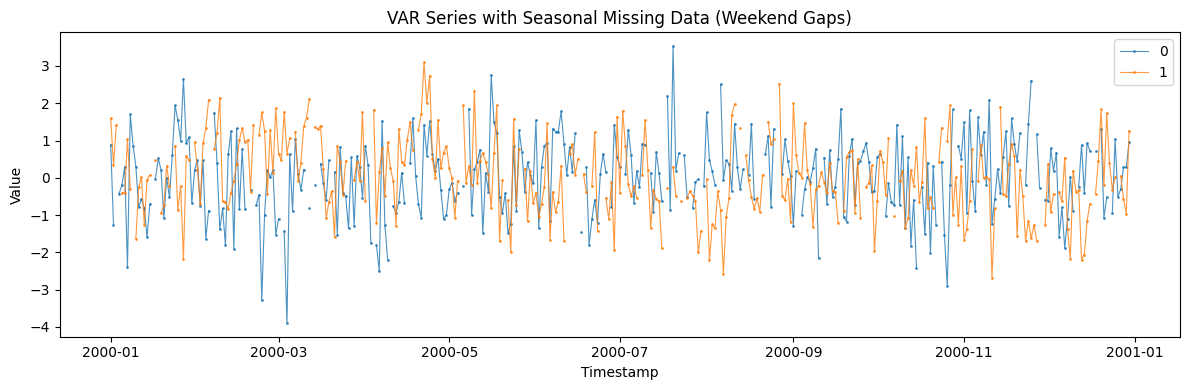

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_var_seasonal["unique_id"].unique().to_list():
    series = df_var_seasonal.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, marker=".", markersize=2, linewidth=0.8)
ax.set_title("VAR Series with Seasonal Missing Data (Weekend Gaps)")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.legend()
plt.tight_layout()
plt.show()

## Does the correlation survive the gaps?

Estimate the cross-series correlation with and without missing data (dropping only the timestamps missing in either series). The estimate stays close, confirming the gaps are missing-at-random with respect to the dependence structure rather than distorting it.

In [ ]:
params_complete = {
    "min_length": 500,
    "max_length": 500,
    "freq": "D",
    "lag_order": 1,
    "missing_data": False,
    "seed": 789,
}

params_missing = {
    "min_length": 500,
    "max_length": 500,
    "freq": "D",
    "lag_order": 1,
    "missing_data": True,
    "missing_pattern": "random",
    "missing_rate": 0.25,
    "seed": 789,
}

gen_complete = VARGenerator(engine="polars", **params_complete)
df_complete = gen_complete.generate(n_series=2)

gen_missing = VARGenerator(engine="polars", **params_missing)
df_missing = gen_missing.generate(n_series=2)

# Calculate correlations
series_0_complete = df_complete.filter(pl.col("unique_id") == "0")[
    "y"
].to_numpy()
series_1_complete = df_complete.filter(pl.col("unique_id") == "1")[
    "y"
].to_numpy()
corr_complete = np.corrcoef(series_0_complete, series_1_complete)[0, 1]

series_0_missing = df_missing.filter(pl.col("unique_id") == "0")[
    "y"
].to_numpy()
series_1_missing = df_missing.filter(pl.col("unique_id") == "1")[
    "y"
].to_numpy()
mask = ~(np.isnan(series_0_missing) | np.isnan(series_1_missing))
corr_missing = np.corrcoef(series_0_missing[mask], series_1_missing[mask])[0, 1]

print(f"Correlation (complete data): {corr_complete:.3f}")
print(f"Correlation (25% missing):   {corr_missing:.3f}")
print(f"Correlation preserved:       {abs(corr_complete - corr_missing) < 0.1}")

Correlation (complete data): 0.069
Correlation (25% missing):   0.041
Correlation preserved:       True


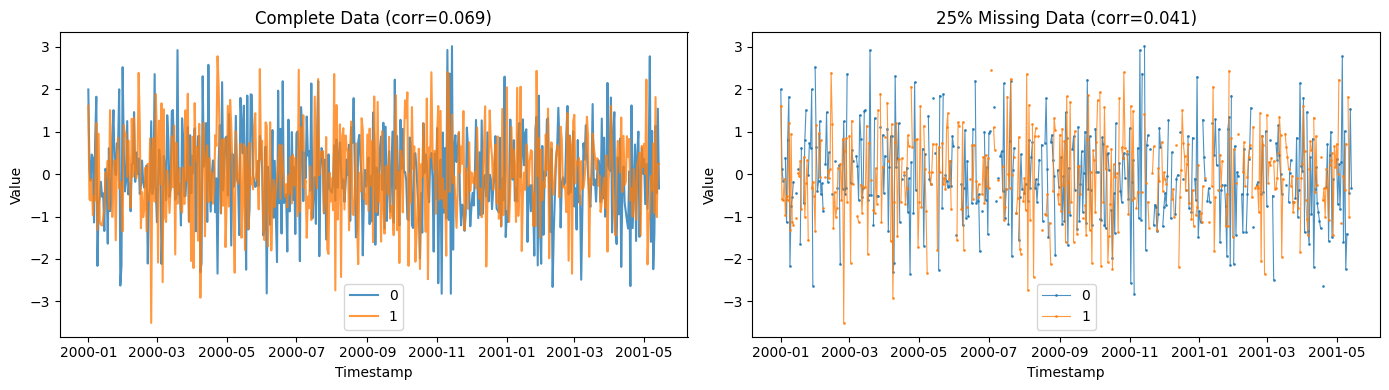

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for uid in df_complete["unique_id"].unique().to_list():
    series = df_complete.filter(pl.col("unique_id") == uid)
    axes[0].plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
axes[0].set_title(f"Complete Data (corr={corr_complete:.3f})")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Value")
axes[0].legend()

for uid in df_missing["unique_id"].unique().to_list():
    series = df_missing.filter(pl.col("unique_id") == uid)
    axes[1].plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8, marker=".", markersize=2, linewidth=0.8)
axes[1].set_title(f"25% Missing Data (corr={corr_missing:.3f})")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()